# 05 - Model

This notebook is in charge of building and evaluating the prediction models used in the project.

The goal will be to assess whether changes in euro area financial stress can help predict unusual increases in perceived Swiss bank risk four weeks later, this is measured by changes in the Swiss bank bond spread.

In [1]:
import pandas as pd
from pathlib import Path
import sklearn as sk

In [2]:
data_dir = Path.cwd().joinpath("swiss-bank-risk-project", "data")

processed_data_folder = data_dir.joinpath("processed")
processed_data_folder.mkdir(parents=True, exist_ok=True)

feature_weekly_data = processed_data_folder.joinpath("feature_weekly_data.csv")

feature_weekly_df = pd.read_csv(feature_weekly_data, parse_dates=["date"])
#display(feature_weekly_df.head())

## Preparing the modelling data

The feature data must be restricted to the period that will be used in the analysis.

The target variable is based on the commercial bank bond spread change over the following 4 weeks.

In [3]:
feature_weekly_df = feature_weekly_df[(feature_weekly_df["date"] >= "2015-01-01") & (feature_weekly_df["date"] <= "2025-07-31")].copy()

feature_weekly_df = feature_weekly_df.sort_values("date").reset_index(drop=True) 
# We want observations to be in chronological order

print("Shape:")
print(feature_weekly_df.shape)


print("Date range:")
print(feature_weekly_df["date"].min())
print(feature_weekly_df["date"].max())


print("Missing values:")
print(feature_weekly_df.isna().sum())


print("First rows:")
display(feature_weekly_df.head())

Shape:
(552, 19)
Date range:
2015-01-02 00:00:00
2025-07-25 00:00:00
Missing values:
date                                     0
ciss_index                               0
chf-eur_exchange_rate_control            0
commercial_bank_bond_yield               0
government_bond_yield                    0
commercial_bank_bond_spread              0
snb_policy_rate                          0
ciss_change                              0
bond_spread_change                       0
commercial_bond_yield_change             0
government_bond_yield_change             0
policy_rate_change                       0
ciss_volatility_past_4_weeks             0
bond_spread_volatility_past_4_weeks      0
exchange_rate_volatility_past_4_weeks    0
ciss_lag_1w                              0
ciss_lag_4w                              0
bond_spread_lag_1w                       0
bond_spread_lag_4w                       0
dtype: int64
First rows:


,date,ciss_index,chf-eur_exchange_rate_control,commercial_bank_bond_yield,government_bond_yield,commercial_bank_bond_spread,snb_policy_rate,ciss_change,bond_spread_change,commercial_bond_yield_change,government_bond_yield_change,policy_rate_change,ciss_volatility_past_4_weeks,bond_spread_volatility_past_4_weeks,exchange_rate_volatility_past_4_weeks,ciss_lag_1w,ciss_lag_4w,bond_spread_lag_1w,bond_spread_lag_4w
0,2015-01-02,0.007444,1.20255,0.4535,0.2280,0.2255,-0.75,-0.009657,-0.0230,-0.0115,0.0115,-0.5,0.006559,0.039160,0.000521,0.017100,0.007930,0.2485,0.3358
1,2015-01-09,0.025402,1.20122,0.3630,0.1078,0.2552,-0.75,0.017958,0.0297,-0.0905,-0.1202,0.0,0.008001,0.020257,0.000781,0.007444,0.013188,0.2255,0.3168
2,2015-01-16,0.028616,1.12876,0.2646,0.0142,0.2504,-0.75,0.003214,-0.0048,-0.0984,-0.0936,0.0,0.009469,0.013237,0.036768,0.025402,0.023025,0.2552,0.2746
3,2015-01-23,0.062939,0.99926,0.0048,-0.3500,0.3548,-0.75,0.034324,0.1044,-0.2598,-0.3642,0.0,0.023181,0.057055,0.095561,0.028616,0.017100,0.2504,0.2485
4,2015-01-30,0.117127,1.02532,0.1148,-0.2908,0.4056,-0.75,0.054188,0.0508,0.1100,0.0592,0.0,0.042605,0.076447,0.093599,0.062939,0.007444,0.3548,0.2255


In [4]:
four_week_forward_commercial_bank_bond_spread = feature_weekly_df["commercial_bank_bond_spread"].shift(-4)

feature_weekly_df.insert(19, "four_week_forward_commercial_bank_bond_spread", four_week_forward_commercial_bank_bond_spread)

four_week_forward_commercial_bank_bond_spread_change = feature_weekly_df["four_week_forward_commercial_bank_bond_spread"] - feature_weekly_df["commercial_bank_bond_spread"]
feature_weekly_df.insert(20, "four_week_forward_commercial_bank_bond_spread_change", four_week_forward_commercial_bank_bond_spread_change)
display(feature_weekly_df.head())
display(feature_weekly_df.tail(4))

,date,ciss_index,chf-eur_exchange_rate_control,commercial_bank_bond_yield,government_bond_yield,commercial_bank_bond_spread,snb_policy_rate,ciss_change,bond_spread_change,commercial_bond_yield_change,...,policy_rate_change,ciss_volatility_past_4_weeks,bond_spread_volatility_past_4_weeks,exchange_rate_volatility_past_4_weeks,ciss_lag_1w,ciss_lag_4w,bond_spread_lag_1w,bond_spread_lag_4w,four_week_forward_commercial_bank_bond_spread,four_week_forward_commercial_bank_bond_spread_change
0,2015-01-02,0.007444,1.20255,0.4535,0.2280,0.2255,-0.75,-0.009657,-0.0230,-0.0115,...,-0.5,0.006559,0.039160,0.000521,0.017100,0.007930,0.2485,0.3358,0.4056,0.1801
1,2015-01-09,0.025402,1.20122,0.3630,0.1078,0.2552,-0.75,0.017958,0.0297,-0.0905,...,0.0,0.008001,0.020257,0.000781,0.007444,0.013188,0.2255,0.3168,0.4162,0.1610
2,2015-01-16,0.028616,1.12876,0.2646,0.0142,0.2504,-0.75,0.003214,-0.0048,-0.0984,...,0.0,0.009469,0.013237,0.036768,0.025402,0.023025,0.2552,0.2746,0.4018,0.1514
3,2015-01-23,0.062939,0.99926,0.0048,-0.3500,0.3548,-0.75,0.034324,0.1044,-0.2598,...,0.0,0.023181,0.057055,0.095561,0.028616,0.017100,0.2504,0.2485,0.4004,0.0456
4,2015-01-30,0.117127,1.02532,0.1148,-0.2908,0.4056,-0.75,0.054188,0.0508,0.1100,...,0.0,0.042605,0.076447,0.093599,0.062939,0.007444,0.3548,0.2255,0.4370,0.0314


,date,ciss_index,chf-eur_exchange_rate_control,commercial_bank_bond_yield,government_bond_yield,commercial_bank_bond_spread,snb_policy_rate,ciss_change,bond_spread_change,commercial_bond_yield_change,...,policy_rate_change,ciss_volatility_past_4_weeks,bond_spread_volatility_past_4_weeks,exchange_rate_volatility_past_4_weeks,ciss_lag_1w,ciss_lag_4w,bond_spread_lag_1w,bond_spread_lag_4w,four_week_forward_commercial_bank_bond_spread,four_week_forward_commercial_bank_bond_spread_change
548,2025-07-04,0.030363,0.93396,0.9386,0.2976,0.6410,0.0,0.006354,0.0020,0.0152,...,0.0,0.003906,0.008776,0.002678,0.024009,0.015220,0.6390,0.62660,NaN,NaN
549,2025-07-11,0.028096,0.93320,0.9658,0.3344,0.6314,0.0,-0.002266,-0.0096,0.0272,...,0.0,0.002924,0.008711,0.003213,0.030363,0.022962,0.6410,0.63725,NaN,NaN
550,2025-07-18,0.030874,0.93158,0.9958,0.3546,0.6412,0.0,0.002778,0.0098,0.0300,...,0.0,0.003127,0.004608,0.002481,0.028096,0.030051,0.6314,0.62180,NaN,NaN
551,2025-07-25,0.032790,0.93282,0.9622,0.3262,0.6360,0.0,0.001916,-0.0052,-0.0336,...,0.0,0.001930,0.004668,0.000994,0.030874,0.024009,0.6412,0.63900,NaN,NaN


## Training and test periods

The data is divided into two periods: a training period, which is used to train the models (2015–2023), and a test period, which is used for the final out-of-sample evaluation (2024–July 2025).

A 4-week gap must be kept between the training and test periods given that the prediction target, the unusual spread widening uses information from the following 4 weeks.

In [5]:
testing_start_date = pd.Timestamp("2024-01-01")

training_end_date = testing_start_date - pd.Timedelta(weeks=4)
# we end it 4 weeks prematurely because we have to compute four_week_forward_commercial_bank_bond_spread_change
# We don't want the data to overlap with that of the testing period.

train_df = feature_weekly_df[feature_weekly_df["date"] < training_end_date].copy()

test_df = feature_weekly_df[feature_weekly_df["date"] >= testing_start_date].copy()

print("Training period:")
print(train_df["date"].min())
print(train_df["date"].max())
print("Training shape:", train_df.shape)


print("Test period:")
print(test_df["date"].min())
print(test_df["date"].max())
print("Test shape:", test_df.shape)
#display(train_df)

Training period:
2015-01-02 00:00:00
2023-12-01 00:00:00
Training shape: (466, 21)
Test period:
2024-01-05 00:00:00
2025-07-25 00:00:00
Test shape: (82, 21)


## Defining unusual spread widening

An unusual increase in perceived bank risk is defined as a future 4-week change in the bank bond spread that exceeds the 80th percentile of the training data.

The remaining observations are classified as normal.

In [6]:
spread_change_threshold = train_df["four_week_forward_commercial_bank_bond_spread_change"].quantile(0.8)
print(spread_change_threshold)

train_df[train_df["four_week_forward_commercial_bank_bond_spread_change"] > spread_change_threshold].shape

0.04075000000000001


(93, 21)

In [7]:
print(train_df["four_week_forward_commercial_bank_bond_spread_change"].isna().sum())

print(test_df["four_week_forward_commercial_bank_bond_spread_change"].isna().sum())


# Remove rows where the 4-week-forward spread change cannot be calculated
train_df = train_df.dropna(subset=["four_week_forward_commercial_bank_bond_spread_change"]).copy()

test_df = test_df.dropna(subset=["four_week_forward_commercial_bank_bond_spread_change"]).copy()


train_df["unusual_spread_widening"] = (train_df["four_week_forward_commercial_bank_bond_spread_change"]> spread_change_threshold).astype(int)
# checks if it's wider than the unsusual spread widening. If it's the case,they become values.
# 1 If it's true, 0 if it's false.

test_df["unusual_spread_widening"] = (test_df["four_week_forward_commercial_bank_bond_spread_change"]> spread_change_threshold).astype(int)


print("Training target:")
print(train_df["unusual_spread_widening"].value_counts())
# counts how many 0s and how many 1s there are in the target column.
print(train_df["unusual_spread_widening"].value_counts(normalize=True) * 100)
# counts how many 0s and how many 1s there are in the target column as a %


print("Testing target:")
print(test_df["unusual_spread_widening"].value_counts())
print(test_df["unusual_spread_widening"].value_counts(normalize=True) * 100)

0
4
Training target:
unusual_spread_widening
0    373
1     93
Name: count, dtype: int64
unusual_spread_widening
0    80.042918
1    19.957082
Name: proportion, dtype: float64
Testing target:
unusual_spread_widening
0    72
1     6
Name: count, dtype: int64
unusual_spread_widening
0    92.307692
1     7.692308
Name: proportion, dtype: float64


In [8]:
train_df["covid_dummy"] = ((train_df["date"] >= "2020-03-16") & (train_df["date"] <= "2020-06-22")).astype(int)
train_df["credit_suisse_dummy"] = ((train_df["date"] >= "2023-03-15") & (train_df["date"] <= "2023-06-12")).astype(int)
train_df["ukraine_war_dummy"] = ((train_df["date"] >= "2022-02-24") & (train_df["date"] <= "2022-06-30")).astype(int)
train_df["snb_floor_dummy"] = ((train_df["date"] >= "2015-01-15") & (train_df["date"] <= "2015-02-27")).astype(int)

print(train_df["covid_dummy"].value_counts())
print(train_df["credit_suisse_dummy"].value_counts())
print(train_df["ukraine_war_dummy"].value_counts())
print(train_df["snb_floor_dummy"].value_counts())

test_df["covid_dummy"] = ((test_df["date"] >= "2020-03-16") & (test_df["date"] <= "2020-06-22")).astype(int)
test_df["credit_suisse_dummy"] = ((test_df["date"] >= "2023-03-15") & (test_df["date"] <= "2023-06-12")).astype(int)
test_df["ukraine_war_dummy"] = ((test_df["date"] >= "2022-02-24") & (test_df["date"] <= "2022-06-30")).astype(int)
test_df["snb_floor_dummy"] = ((test_df["date"] >= "2015-01-15") & (test_df["date"] <= "2015-02-27")).astype(int)

print(test_df["covid_dummy"].value_counts())
print(test_df["credit_suisse_dummy"].value_counts())
print(test_df["ukraine_war_dummy"].value_counts())
print(test_df["snb_floor_dummy"].value_counts())

covid_dummy
0    452
1     14
Name: count, dtype: int64
credit_suisse_dummy
0    453
1     13
Name: count, dtype: int64
ukraine_war_dummy
0    448
1     18
Name: count, dtype: int64
snb_floor_dummy
0    459
1      7
Name: count, dtype: int64
covid_dummy
0    78
Name: count, dtype: int64
credit_suisse_dummy
0    78
Name: count, dtype: int64
ukraine_war_dummy
0    78
Name: count, dtype: int64
snb_floor_dummy
0    78
Name: count, dtype: int64


In [9]:
y_train = train_df["unusual_spread_widening"]
y_test = test_df["unusual_spread_widening"]

## Logistic regression models

Three logistic regression models are estimated. Each model takes into account additional information.

The first model uses only the weekly change in the CISS index in order to act as a baseline for the relationship between changes in euro area financial stress and future Swiss bank risk.

In [10]:
# One bracket returns a Series, while two brackets return a DataFrame
X1_train = train_df[["ciss_change"]]
X1_test = test_df[["ciss_change"]]

### Model 2 - Adding financial controls

The second model adds the CHF/EUR exchange rate and the SNB policy rate.

These variables are included to account for additional financial and monetary conditions that may influence Swiss bank bond spread changes.

In [11]:
X2_train = train_df[["ciss_change", "chf-eur_exchange_rate_control", "snb_policy_rate"]]

X2_test = test_df[["ciss_change", "chf-eur_exchange_rate_control", "snb_policy_rate"]]

### Model 3 - Adding crisis periods

The third logistic regression model adds indicators for important periods of financial and economic stress.

The model now accounts for exceptional events and geopolitical crises that may have affected the Swiss financial market independently of financial stress in the euro area.

In [12]:
X3_train = train_df[["ciss_change", "chf-eur_exchange_rate_control", "snb_policy_rate", "covid_dummy", "ukraine_war_dummy", "snb_floor_dummy", "credit_suisse_dummy"]]

X3_test = test_df[["ciss_change", "chf-eur_exchange_rate_control", "snb_policy_rate", "covid_dummy", "ukraine_war_dummy", "snb_floor_dummy", "credit_suisse_dummy"]]

In [13]:
# We check that all training data sets have the same number of observations
# [0] for shape gives you the rows
if X1_train.shape[0] == X2_train.shape[0] == X3_train.shape[0] == y_train.shape[0]:
    print("The training predictors and target have the same number of observations")

# Check that all testing data sets have the same number of observations
if X1_test.shape[0] == X2_test.shape[0] == X3_test.shape[0] == y_test.shape[0]:
    print("The testing predictors and target have the same number of observations")

print("Model 1 training:", X1_train.shape)
print("Model 2 training:", X2_train.shape)
print("Model 3 training:", X3_train.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

The training predictors and target have the same number of observations
The testing predictors and target have the same number of observations
Model 1 training: (466, 1)
Model 2 training: (466, 3)
Model 3 training: (466, 7)
Training target: (466,)
Testing target: (78,)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model_1 = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression())])
model_2 = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression())])
model_3 = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression())])

# Then you fit the model with data
model_1.fit(X1_train, y_train)
model_2.fit(X2_train, y_train)
model_3.fit(X3_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [15]:
model_1_probabilities = model_1.predict_proba(X1_test)[:, 1]
model_2_probabilities = model_2.predict_proba(X2_test)[:, 1]
model_3_probabilities = model_3.predict_proba(X3_test)[:, 1]

# These are the predicted probabilities of an unusual bank bond spread widening in the following 4 weeks for each week in the test period, for model 2.

## Time-series cross-validation

The models are evaluated using time-ordered cross-validation.

This allows the models to be trained on past data and tested on later observations, while preserving the chronological order of the data.

In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

ts_cross_validation = TimeSeriesSplit(n_splits=5, gap=4)
model_1_cv_scores = cross_val_score(model_1, X1_train, y_train, cv=ts_cross_validation, scoring="roc_auc")

model_2_cv_scores = cross_val_score(model_2, X2_train, y_train, cv=ts_cross_validation, scoring="roc_auc")

model_3_cv_scores = cross_val_score(model_3, X3_train, y_train, cv=ts_cross_validation, scoring="roc_auc")

print("Model 1 scores:", model_1_cv_scores)
print("Model 1 average:", model_1_cv_scores.mean())

print("Model 2 scores:", model_2_cv_scores)
print("Model 2 average:", model_2_cv_scores.mean())

print("Model 3 scores:", model_3_cv_scores)
print("Model 3 average:", model_3_cv_scores.mean())

Model 1 scores: [0.72244898 0.50612245 0.65036232 0.63605442 0.56846154]
Model 1 average: 0.6166899415284509
Model 2 scores: [0.70408163 0.39795918 0.73188406 0.68452381 0.44538462]
Model 2 average: 0.592766659841194
Model 3 scores: [0.70408163 0.3877551  0.67210145 0.65901361 0.55692308]
Model 3 average: 0.5959749732668987


## Decision tree

A decision tree is a model that generates predictions by repeatedly splitting the data into different groups based on the values of the predictors.

The same predictors as the third logistic regression model will be used to estimate the decision tree.

In contrast to the logistic models, this offers a non-linear perspective where threshold effects in the predictors on the target variable can be taken into account.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


decision_tree = DecisionTreeClassifier(random_state=42)


tree_parameters = {"max_depth": [2, 3, 4, 5], "min_samples_leaf": [5, 10, 20]}


tree_search = GridSearchCV(decision_tree, tree_parameters, cv=ts_cross_validation, scoring="roc_auc")

tree_search.fit(X3_train, y_train)

best_tree = tree_search.best_estimator_


print("Best tree:")
print(tree_search.best_params_)

print("Best average ROC-AUC:")
print(tree_search.best_score_)


decision_tree_probabilities = best_tree.predict_proba(X3_test)[:, 1]

Best tree:
{'max_depth': 3, 'min_samples_leaf': 20}
Best average ROC-AUC:
0.6610749550656383


## Out-of-sample evaluation

The models have now been trained on data from 2015 to 2023 and will be tested on data from 2024 to July 2025.

Their performance is measured using the following measures:
- ROC-AUC, which measures how well the model separates unusual above-threshold bank bond spread widenings from normal cases.
- Recall, which measures how many actual unusual bank bond spread widenings the model was able to detect.
- Precision, which measures how many of the predicted unusual bank bond spread widenings were actually unusual.
- F1 score, which balances precision and recall into a single measure.
- Confusion matrix, which shows the number of correct and incorrect classifications, separating them into true negatives, false negatives, true positives and false positives.   

In [18]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score


model_1_roc_auc = roc_auc_score(y_test, model_1_probabilities)
model_2_roc_auc = roc_auc_score(y_test, model_2_probabilities)
model_3_roc_auc = roc_auc_score(y_test, model_3_probabilities)
decision_tree_roc_auc = roc_auc_score(y_test, decision_tree_probabilities)

print("Model 1 ROC-AUC:", model_1_roc_auc)
print("Model 2 ROC-AUC:", model_2_roc_auc)
print("Model 3 ROC-AUC:", model_3_roc_auc)
print("Decision Tree ROC-AUC:", decision_tree_roc_auc)

model_1_predictions = (model_1_probabilities >= 0.5).astype(int)
model_2_predictions = (model_2_probabilities >= 0.5).astype(int)
model_3_predictions = (model_3_probabilities >= 0.5).astype(int)
decision_tree_predictions = (decision_tree_probabilities >= 0.5).astype(int)


model_1_precision = precision_score(y_test, model_1_predictions, zero_division=0)
model_1_recall = recall_score(y_test, model_1_predictions)
model_1_f1 = f1_score(y_test, model_1_predictions)

model_2_precision = precision_score(y_test, model_2_predictions, zero_division=0)
model_2_recall = recall_score(y_test, model_2_predictions)
model_2_f1 = f1_score(y_test, model_2_predictions)

model_3_precision = precision_score(y_test, model_3_predictions, zero_division=0)
model_3_recall = recall_score(y_test, model_3_predictions)
model_3_f1 = f1_score(y_test, model_3_predictions)

decision_tree_precision = precision_score(y_test, decision_tree_predictions, zero_division=0)
decision_tree_recall = recall_score(y_test, decision_tree_predictions)
decision_tree_f1 = f1_score(y_test, decision_tree_predictions)


print("Model 1:", model_1_precision, model_1_recall, model_1_f1)
print("Model 2:", model_2_precision, model_2_recall, model_2_f1)
print("Model 3:", model_3_precision, model_3_recall, model_3_f1)
print("Decision Tree:", decision_tree_precision, decision_tree_recall, decision_tree_f1)

model_1_confusion_matrix = confusion_matrix(y_test, model_1_predictions)
model_2_confusion_matrix = confusion_matrix(y_test, model_2_predictions)
model_3_confusion_matrix = confusion_matrix(y_test, model_3_predictions)
decision_tree_confusion_matrix = confusion_matrix(y_test, decision_tree_predictions)

print("Model 1 confusion matrix:")
print(model_1_confusion_matrix)

print("Model 2 confusion matrix:")
print(model_2_confusion_matrix)

print("Model 3 confusion matrix:")
print(model_3_confusion_matrix)

print("Decision Tree confusion matrix:")
print(decision_tree_confusion_matrix)


model_results = pd.DataFrame({
    "Model": [
        "Model 1",
        "Model 2",
        "Model 3",
        "Decision Tree"
    ],
    "ROC-AUC": [
        model_1_roc_auc,
        model_2_roc_auc,
        model_3_roc_auc,
        decision_tree_roc_auc
    ],
    "Precision": [
        model_1_precision,
        model_2_precision,
        model_3_precision,
        decision_tree_precision
    ],
    "Recall": [
        model_1_recall,
        model_2_recall,
        model_3_recall,
        decision_tree_recall
    ],
    "F1 Score": [
        model_1_f1,
        model_2_f1,
        model_3_f1,
        decision_tree_f1
    ]
})

display(model_results)


best_roc_auc_model = model_results.loc[
    model_results["ROC-AUC"].idxmax(),
    "Model"
]

best_f1_model = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on ROC-AUC:", best_roc_auc_model)
print("Best model based on F1 Score:", best_f1_model)


print("The 2024-2025 test period is only used for final evaluation.")
print("We do not configure the models again using these test results.")

Model 1 ROC-AUC: 0.6180555555555556
Model 2 ROC-AUC: 0.5185185185185185
Model 3 ROC-AUC: 0.4976851851851852
Decision Tree ROC-AUC: 0.43634259259259256
Model 1: 0.0 0.0 0.0
Model 2: 0.0 0.0 0.0
Model 3: 0.0 0.0 0.0
Decision Tree: 0.06382978723404255 0.5 0.11320754716981132
Model 1 confusion matrix:
[[72  0]
 [ 6  0]]
Model 2 confusion matrix:
[[70  2]
 [ 6  0]]
Model 3 confusion matrix:
[[72  0]
 [ 6  0]]
Decision Tree confusion matrix:
[[28 44]
 [ 3  3]]


,Model,ROC-AUC,Precision,Recall,F1 Score
0,Model 1,0.618056,0.00000,0.0,0.000000
1,Model 2,0.518519,0.00000,0.0,0.000000
2,Model 3,0.497685,0.00000,0.0,0.000000
3,Decision Tree,0.436343,0.06383,0.5,0.113208


Best model based on ROC-AUC: Model 1
Best model based on F1 Score: Decision Tree
The 2024-2025 test period is only used for final evaluation.
We do not configure the models again using these test results.


### Interpretation of the out-of-sample results

Model 1 achieves the highest test ROC-AUC, at approximately 0.62, meaning that the weekly change in CISS provides some ability to distinguish future unusual spread widenings from normal observations.

Model 2 achieves a lower ROC-AUC score of approximately 0.52 after adding the CHF/EUR exchange rate and the SNB policy rate. Therefore, these additional control variables do not improve the out-of-sample performance of the model.

Model 3 lags closely behind with a ROC-AUC of approximately 0.50 after adding the geopolitical and crisis dummy variables on top of the previous variables.

The decision tree has the lowest ROC-AUC, at approximately 0.44. It is able to detect some unusual events, but this comes with many false positives.

Overall, Model 1 performs best according to ROC-AUC, suggesting that the weekly change in euro area financial stress on its own contains some information about future unusual spread widening. However, at the 0.5 classification threshold, none of the logistic regression models successfully identify the unusual events in the test period.

## Model interpretation

The coefficients of the logistic regression models are examined to better understand the relationship between each predictor and the probability of unusual spread widening.

It's important to closely look at the CISS variable, as we want to check whether its relationship with future unusual spread widenings remains consistent throughout the three models.

In [19]:
model_1_coefficients = model_1.named_steps["model"].coef_[0]
model_2_coefficients = model_2.named_steps["model"].coef_[0]
model_3_coefficients = model_3.named_steps["model"].coef_[0]

model_1_coefficients_df = pd.DataFrame({"Predictor": X1_train.columns, "Coefficient": model_1_coefficients})

model_2_coefficients_df = pd.DataFrame({"Predictor": X2_train.columns, "Coefficient": model_2_coefficients})

model_3_coefficients_df = pd.DataFrame({"Predictor": X3_train.columns, "Coefficient": model_3_coefficients})

def coefficient_direction(coefficient):
    if coefficient > 0:
        return "Higher probability of unusual spread widening"
    elif coefficient < 0:
        return "Lower probability of unusual spread widening"
    else:
        return "No relationship"

model_1_coefficients_df["Direction"] = model_1_coefficients_df["Coefficient"].apply(coefficient_direction)
model_2_coefficients_df["Direction"] = model_2_coefficients_df["Coefficient"].apply(coefficient_direction)
model_3_coefficients_df["Direction"] = model_3_coefficients_df["Coefficient"].apply(coefficient_direction)

print("Model 1:")
display(model_1_coefficients_df)

print("Model 2:")
display(model_2_coefficients_df)

print("Model 3:")
display(model_3_coefficients_df)

ciss_coefficients = pd.DataFrame({"Model": ["Model 1", "Model 2", "Model 3"], "CISS Coefficient": 
                                  [model_1_coefficients_df.loc[model_1_coefficients_df["Predictor"] == "ciss_change","Coefficient"].iloc[0],
                                   model_2_coefficients_df.loc[model_2_coefficients_df["Predictor"] == "ciss_change","Coefficient"].iloc[0],
                                   model_3_coefficients_df.loc[model_3_coefficients_df["Predictor"] == "ciss_change","Coefficient"].iloc[0]]})


print("CISS coefficient in each model:")
display(ciss_coefficients)

Model 1:


,Predictor,Coefficient,Direction
0,ciss_change,0.279927,Higher probability of unusual spread widening


Model 2:


,Predictor,Coefficient,Direction
0,ciss_change,0.247559,Higher probability of unusual spread widening
1,chf-eur_exchange_rate_control,-0.628266,Lower probability of unusual spread widening
2,snb_policy_rate,-0.210371,Lower probability of unusual spread widening


Model 3:


,Predictor,Coefficient,Direction
0,ciss_change,0.206348,Higher probability of unusual spread widening
1,chf-eur_exchange_rate_control,-0.246896,Lower probability of unusual spread widening
2,snb_policy_rate,-0.000663,Lower probability of unusual spread widening
3,covid_dummy,-0.014766,Lower probability of unusual spread widening
4,ukraine_war_dummy,0.661797,Higher probability of unusual spread widening
5,snb_floor_dummy,0.307861,Higher probability of unusual spread widening
6,credit_suisse_dummy,0.235968,Higher probability of unusual spread widening


CISS coefficient in each model:


,Model,CISS Coefficient
0,Model 1,0.279927
1,Model 2,0.247559
2,Model 3,0.206348


### Interpretation of the model coefficients

The CISS coefficient is positive in all three models, meaning that it has a consistent positive relationship with future unusual spread widening.

Nonetheless, its coefficient decreases as more variables are added, suggesting that its relationship with future unusual spread widening becomes weaker once additional factors are taken into account.

The Ukraine war, SNB floor and Credit Suisse dummy variables all have positive coefficients, while the exchange rate, SNB policy rate and COVID dummy have negative coefficients.

,Model,Cross-validation ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Model 1,0.616690,0.618056,0.00000,0.0,0.000000
1,Model 2,0.592767,0.518519,0.00000,0.0,0.000000
2,Model 3,0.595975,0.497685,0.00000,0.0,0.000000
3,Decision Tree,0.661075,0.436343,0.06383,0.5,0.113208


Best model based on cross-validation ROC-AUC: Decision Tree
Best model based on test ROC-AUC: Model 1
Best model based on recall: Decision Tree
Best model based on F1 score: Decision Tree


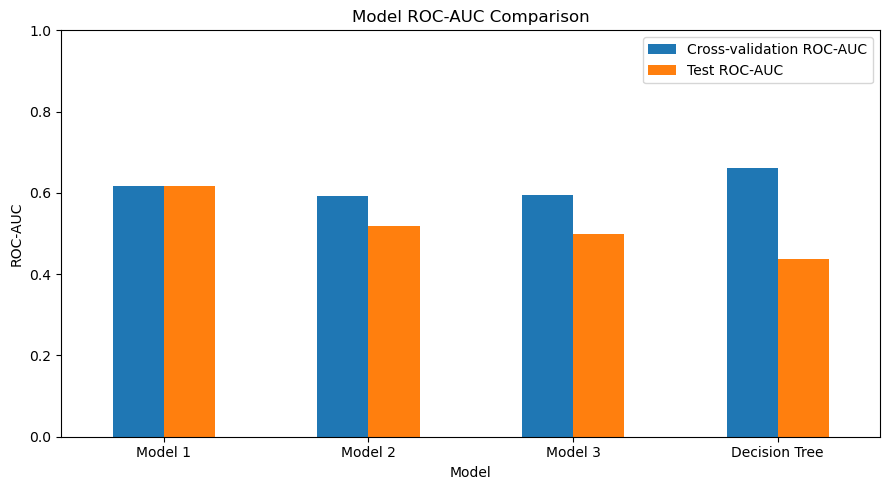

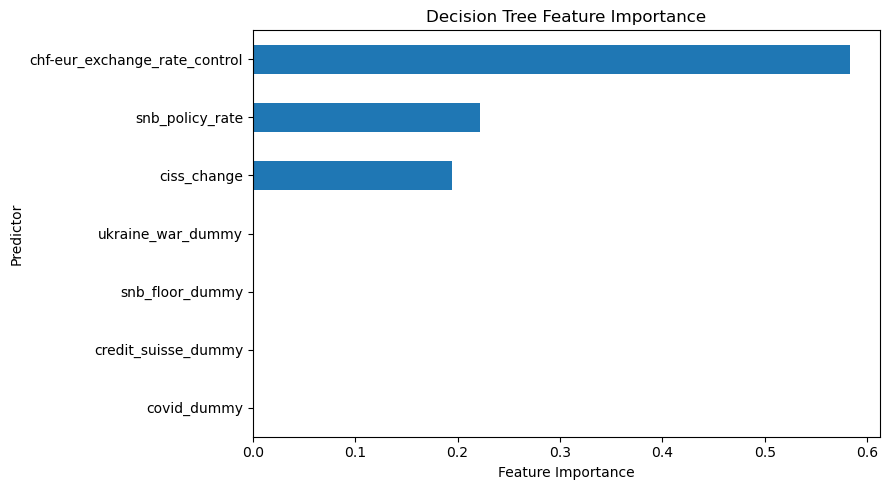

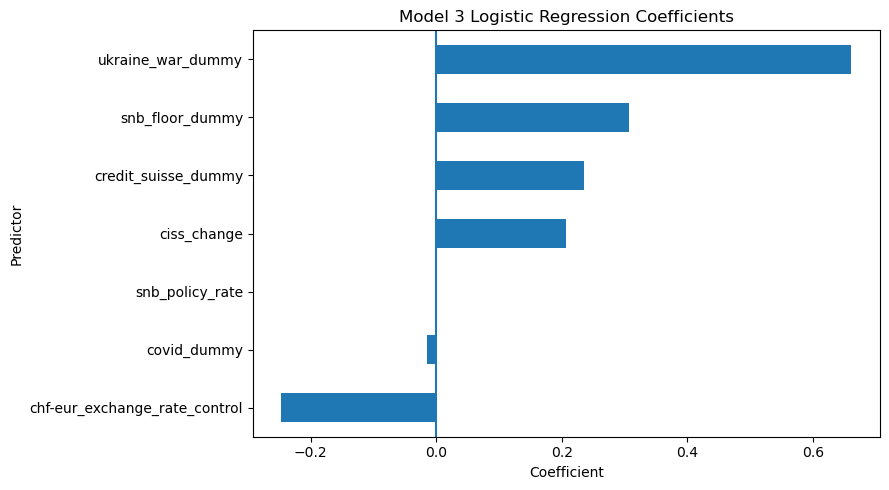

In [20]:
import matplotlib.pyplot as plt


final_model_comparison = pd.DataFrame({"Model": ["Model 1", "Model 2", "Model 3", "Decision Tree"],
                                       "Cross-validation ROC-AUC": [model_1_cv_scores.mean(), model_2_cv_scores.mean(), 
                                                                    model_3_cv_scores.mean(), tree_search.best_score_],
                                       "Test ROC-AUC": [model_1_roc_auc, model_2_roc_auc, model_3_roc_auc, decision_tree_roc_auc],
                                       "Precision": [model_1_precision, model_2_precision, model_3_precision, decision_tree_precision],
                                       "Recall": [model_1_recall, model_2_recall, model_3_recall, decision_tree_recall],
                                       "F1 Score": [model_1_f1, model_2_f1, model_3_f1, decision_tree_f1]})

display(final_model_comparison)


best_cv_model = final_model_comparison.loc[final_model_comparison["Cross-validation ROC-AUC"].idxmax(), "Model"]

best_test_roc_auc_model = final_model_comparison.loc[final_model_comparison["Test ROC-AUC"].idxmax(), "Model"]

best_recall_model = final_model_comparison.loc[final_model_comparison["Recall"].idxmax(), "Model"]

best_f1_model = final_model_comparison.loc[final_model_comparison["F1 Score"].idxmax(), "Model"]


print("Best model based on cross-validation ROC-AUC:", best_cv_model)
print("Best model based on test ROC-AUC:", best_test_roc_auc_model)
print("Best model based on recall:", best_recall_model)
print("Best model based on F1 score:", best_f1_model)

roc_auc_comparison = final_model_comparison[["Model", "Cross-validation ROC-AUC", "Test ROC-AUC"]
    ].set_index("Model")

roc_auc_comparison.plot(kind="bar", figsize=(9, 5))

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

tree_feature_importance = pd.DataFrame({"Predictor": X3_train.columns, "Importance": best_tree.feature_importances_})

tree_feature_importance = tree_feature_importance.sort_values("Importance", ascending=True)

tree_feature_importance.plot(x="Predictor", y="Importance", kind="barh", figsize=(9, 5), legend=False)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

model_3_coefficients_df = model_3_coefficients_df.sort_values("Coefficient", ascending=True)

model_3_coefficients_df.plot(x="Predictor", y="Coefficient", kind="barh", figsize=(9, 5), legend=False)

plt.title("Model 3 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.axvline(0)
plt.tight_layout()
plt.show()

## Conclusion

The results show that changes in euro area financial stress have some predictive power for unusual widening in Swiss commercial bank bond spreads over the following four weeks.

Model 1, which only uses the weekly change in the CISS index, performs best on the final test period based on ROC-AUC.

Additional control and dummy variables do not seem to improve out-of-sample performance.